In [1]:
import sys

print("Python executable:")
print(sys.executable)

print("\nPython version:")
print(sys.version)

Python executable:
C:\Users\Lenovo\anaconda3\envs\fincascade\python.exe

Python version:
3.11.16 | packaged by Anaconda, Inc. | (main, Aug 27 2026, 14:36:16) [MSC v.1942 64 bit (AMD64)]


In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import networkx as nx

# Current notebook location
NOTEBOOK_DIR = Path.cwd()

# FinCascade root folder
ROOT = NOTEBOOK_DIR.parent

# Project folders
DATA_DIR = ROOT / "data"
MODEL_DIR = ROOT / "models"
GRAPH_DIR = ROOT / "graph"
SIMULATION_DIR = ROOT / "simulation"
BACKEND_DIR = ROOT / "backend"

print("Notebook folder :", NOTEBOOK_DIR)
print("Project root    :", ROOT)
print("Data folder     :", DATA_DIR)

print("\nLibraries imported successfully.")

Notebook folder : C:\Users\Lenovo\Desktop\FinCascade\notebooks
Project root    : C:\Users\Lenovo\Desktop\FinCascade
Data folder     : C:\Users\Lenovo\Desktop\FinCascade\data

Libraries imported successfully.


In [6]:
entities = {
    # Market Indices
    "^NSEI":        ("NIFTY 50", "Index", "Market"),
    "^NSEBANK":     ("Bank Nifty", "Index", "Banking"),

    # Currency / Commodities
    "INR=X":        ("USD/INR", "Currency", "Macro"),
    "CL=F":         ("Crude Oil", "Commodity", "Energy"),
    "GC=F":         ("Gold", "Commodity", "Safe Haven"),

    # Banking
    "HDFCBANK.NS":  ("HDFC Bank", "Company", "Banking"),
    "ICICIBANK.NS": ("ICICI Bank", "Company", "Banking"),
    "SBIN.NS":      ("SBI", "Company", "Banking"),
    "AXISBANK.NS":  ("Axis Bank", "Company", "Banking"),

    # IT
    "TCS.NS":       ("TCS", "Company", "IT"),
    "INFY.NS":      ("Infosys", "Company", "IT"),
    "HCLTECH.NS":   ("HCL Tech", "Company", "IT"),
    "WIPRO.NS":     ("Wipro", "Company", "IT"),

    # Energy
    "RELIANCE.NS":  ("Reliance", "Company", "Energy"),
    "ONGC.NS":      ("ONGC", "Company", "Energy"),

    # Auto
    "TMPV.NS": ("Tata Motors Passenger Vehicles", "Company", "Auto"),
    "M&M.NS":        ("Mahindra & Mahindra", "Company", "Auto"),
    "MARUTI.NS":     ("Maruti Suzuki", "Company", "Auto"),

    # Realty
    "DLF.NS":        ("DLF", "Company", "Realty"),
    "GODREJPROP.NS": ("Godrej Properties", "Company", "Realty"),

    # Pharma
    "SUNPHARMA.NS": ("Sun Pharma", "Company", "Pharma"),
    "DRREDDY.NS":   ("Dr Reddy's", "Company", "Pharma"),

    # FMCG
    "HINDUNILVR.NS": ("Hindustan Unilever", "Company", "FMCG"),
    "ITC.NS":        ("ITC", "Company", "FMCG"),

    # NBFC
    "BAJFINANCE.NS": ("Bajaj Finance", "Company", "NBFC"),
    "BAJAJFINSV.NS": ("Bajaj Finserv", "Company", "NBFC")
}

metadata = pd.DataFrame(
    [
        {
            "ticker": ticker,
            "name": details[0],
            "type": details[1],
            "sector": details[2]
        }
        for ticker, details in entities.items()
    ]
)

print("Total entities:", len(metadata))
metadata

Total entities: 26


,ticker,name,type,sector
0,^NSEI,NIFTY 50,Index,Market
1,^NSEBANK,Bank Nifty,Index,Banking
2,INR=X,USD/INR,Currency,Macro
3,CL=F,Crude Oil,Commodity,Energy
4,GC=F,Gold,Commodity,Safe Haven
5,HDFCBANK.NS,HDFC Bank,Company,Banking
6,ICICIBANK.NS,ICICI Bank,Company,Banking
7,SBIN.NS,SBI,Company,Banking
8,AXISBANK.NS,Axis Bank,Company,Banking
9,TCS.NS,TCS,Company,IT


In [7]:
metadata.to_csv(DATA_DIR / "entities.csv", index=False)

print("Saved:", DATA_DIR / "entities.csv")

Saved: C:\Users\Lenovo\Desktop\FinCascade\data\entities.csv


In [8]:
START_DATE = "2021-01-01"
END_DATE = "2026-09-02"

tickers = list(entities.keys())

raw_data = yf.download(
    tickers,
    start=START_DATE,
    end=END_DATE,
    interval="1d",
    auto_adjust=True,
    progress=False,
    threads=True
)

print("Download complete.")
print("Raw data shape:", raw_data.shape)

Download complete.
Raw data shape: (1477, 130)


In [9]:
close_prices = raw_data["Close"].copy()

close_prices.index = pd.to_datetime(close_prices.index)
close_prices = close_prices.sort_index()

print("Shape:", close_prices.shape)

print("\nDate range:")
print(close_prices.index.min(), "to", close_prices.index.max())

close_prices.head()

Shape: (1477, 26)

Date range:
2021-01-01 00:00:00 to 2026-09-01 00:00:00


Ticker,AXISBANK.NS,BAJAJFINSV.NS,BAJFINANCE.NS,CL=F,DLF.NS,DRREDDY.NS,GC=F,GODREJPROP.NS,HCLTECH.NS,HDFCBANK.NS,...,MARUTI.NS,ONGC.NS,RELIANCE.NS,SBIN.NS,SUNPHARMA.NS,TCS.NS,TMPV.NS,WIPRO.NS,^NSEBANK,^NSEI
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-01,620.727478,884.299316,514.064087,NaN,227.257492,1009.432129,NaN,1420.384277,751.725830,663.905701,...,7298.334473,67.063965,897.047119,253.242310,561.122314,2521.074463,181.694244,176.860580,31225.486328,14018.500000
2021-01-04,621.623108,887.120544,507.838013,47.619999,232.930588,1015.383057,1944.699951,1400.430664,775.373230,659.689514,...,7308.772461,69.762375,898.559143,254.737839,568.792114,2616.812012,186.370560,180.642960,31212.085938,14132.900391
2021-01-05,661.177307,879.354675,498.374847,49.930000,230.499252,1018.204407,1952.699951,1399.833618,784.033325,664.674316,...,7264.315918,68.323227,887.388306,255.372284,567.898132,2662.915283,188.221603,185.154510,31721.880859,14199.500000
2021-01-06,651.027527,875.915283,489.739227,50.630001,229.831848,1018.474304,1906.900024,1453.573853,773.633240,661.809143,...,7238.837402,69.762375,863.986084,258.363373,569.639160,2627.186279,190.364899,185.200073,31797.531250,14146.250000
2021-01-07,667.794495,896.017761,494.675323,50.830002,233.979385,1015.123108,1912.300049,1445.811401,761.255981,659.805847,...,7179.482910,70.445953,862.586975,260.765289,566.439392,2611.086182,191.680130,185.359558,31955.628906,14137.349609


In [10]:
download_check = pd.DataFrame({
    "ticker": close_prices.columns,
    "records": close_prices.notna().sum(),
    "missing": close_prices.isna().sum(),
    "missing_pct": close_prices.isna().mean() * 100
})

download_check["name"] = download_check["ticker"].map(
    {k: v[0] for k, v in entities.items()}
)

download_check = download_check[
    ["ticker", "name", "records", "missing", "missing_pct"]
].sort_values("missing_pct", ascending=False)

download_check

,ticker,name,records,missing,missing_pct
Ticker,,,,,
^NSEBANK,^NSEBANK,Bank Nifty,1398,79,5.348680
^NSEI,^NSEI,NIFTY 50,1399,78,5.280975
BAJFINANCE.NS,BAJFINANCE.NS,Bajaj Finance,1404,73,4.942451
DLF.NS,DLF.NS,DLF,1404,73,4.942451
DRREDDY.NS,DRREDDY.NS,Dr Reddy's,1404,73,4.942451
GODREJPROP.NS,GODREJPROP.NS,Godrej Properties,1404,73,4.942451
HDFCBANK.NS,HDFCBANK.NS,HDFC Bank,1404,73,4.942451
HCLTECH.NS,HCLTECH.NS,HCL Tech,1404,73,4.942451
AXISBANK.NS,AXISBANK.NS,Axis Bank,1404,73,4.942451


In [11]:
close_prices.to_csv(DATA_DIR / "market_prices_raw.csv")

print("Saved:", DATA_DIR / "market_prices_raw.csv")
print("Rows:", close_prices.shape[0])
print("Columns:", close_prices.shape[1])

Saved: C:\Users\Lenovo\Desktop\FinCascade\data\market_prices_raw.csv
Rows: 1477
Columns: 26


In [12]:
# Use NIFTY 50 valid trading dates as our master calendar
nifty_dates = close_prices["^NSEI"].dropna().index

aligned_prices = close_prices.reindex(nifty_dates)

print("Original shape :", close_prices.shape)
print("Aligned shape  :", aligned_prices.shape)

aligned_prices.head()

Original shape : (1477, 26)
Aligned shape  : (1399, 26)


Ticker,AXISBANK.NS,BAJAJFINSV.NS,BAJFINANCE.NS,CL=F,DLF.NS,DRREDDY.NS,GC=F,GODREJPROP.NS,HCLTECH.NS,HDFCBANK.NS,...,MARUTI.NS,ONGC.NS,RELIANCE.NS,SBIN.NS,SUNPHARMA.NS,TCS.NS,TMPV.NS,WIPRO.NS,^NSEBANK,^NSEI
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-01,620.727478,884.299316,514.064087,NaN,227.257492,1009.432129,NaN,1420.384277,751.725830,663.905701,...,7298.334473,67.063965,897.047119,253.242310,561.122314,2521.074463,181.694244,176.860580,31225.486328,14018.500000
2021-01-04,621.623108,887.120544,507.838013,47.619999,232.930588,1015.383057,1944.699951,1400.430664,775.373230,659.689514,...,7308.772461,69.762375,898.559143,254.737839,568.792114,2616.812012,186.370560,180.642960,31212.085938,14132.900391
2021-01-05,661.177307,879.354675,498.374847,49.930000,230.499252,1018.204407,1952.699951,1399.833618,784.033325,664.674316,...,7264.315918,68.323227,887.388306,255.372284,567.898132,2662.915283,188.221603,185.154510,31721.880859,14199.500000
2021-01-06,651.027527,875.915283,489.739227,50.630001,229.831848,1018.474304,1906.900024,1453.573853,773.633240,661.809143,...,7238.837402,69.762375,863.986084,258.363373,569.639160,2627.186279,190.364899,185.200073,31797.531250,14146.250000
2021-01-07,667.794495,896.017761,494.675323,50.830002,233.979385,1015.123108,1912.300049,1445.811401,761.255981,659.805847,...,7179.482910,70.445953,862.586975,260.765289,566.439392,2611.086182,191.680130,185.359558,31955.628906,14137.349609


In [13]:
missing_after_alignment = pd.DataFrame({
    "missing": aligned_prices.isna().sum(),
    "missing_pct": aligned_prices.isna().mean() * 100
}).sort_values("missing", ascending=False)

missing_after_alignment

,missing,missing_pct
Ticker,,
GC=F,46,3.288063
CL=F,46,3.288063
INR=X,4,0.285919
^NSEBANK,1,0.071480
BAJAJFINSV.NS,0,0.000000
AXISBANK.NS,0,0.000000
DRREDDY.NS,0,0.000000
GODREJPROP.NS,0,0.000000
DLF.NS,0,0.000000


In [14]:
clean_prices = aligned_prices.ffill(limit=2)

print("Missing values before:", aligned_prices.isna().sum().sum())
print("Missing values after :", clean_prices.isna().sum().sum())

Missing values before: 97
Missing values after : 2


In [15]:
remaining_missing = pd.DataFrame({
    "missing": clean_prices.isna().sum(),
    "missing_pct": clean_prices.isna().mean() * 100
})

remaining_missing = remaining_missing[
    remaining_missing["missing"] > 0
].sort_values("missing", ascending=False)

remaining_missing

,missing,missing_pct
Ticker,,
CL=F,1,0.07148
GC=F,1,0.07148


In [16]:
final_prices = clean_prices.dropna().copy()

print("Before:", clean_prices.shape)
print("After :", final_prices.shape)

print("\nRemaining missing values:")
print(final_prices.isna().sum().sum())

Before: (1399, 26)
After : (1398, 26)

Remaining missing values:
0


In [17]:
final_prices.to_csv(DATA_DIR / "market_prices_clean.csv")

print("Saved:", DATA_DIR / "market_prices_clean.csv")
print("Rows   :", final_prices.shape[0])
print("Columns:", final_prices.shape[1])

Saved: C:\Users\Lenovo\Desktop\FinCascade\data\market_prices_clean.csv
Rows   : 1398
Columns: 26


In [18]:
returns = final_prices.pct_change().dropna()

print("Returns shape:", returns.shape)
returns.head()

Returns shape: (1397, 26)


Ticker,AXISBANK.NS,BAJAJFINSV.NS,BAJFINANCE.NS,CL=F,DLF.NS,DRREDDY.NS,GC=F,GODREJPROP.NS,HCLTECH.NS,HDFCBANK.NS,...,MARUTI.NS,ONGC.NS,RELIANCE.NS,SBIN.NS,SUNPHARMA.NS,TCS.NS,TMPV.NS,WIPRO.NS,^NSEBANK,^NSEI
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-05,0.063631,-0.008754,-0.018634,0.048509,-0.010438,0.002779,0.004114,-0.000426,0.011169,0.007556,...,-0.006083,-0.020629,-0.012432,0.002491,-0.001572,0.017618,0.009932,0.024975,0.016333,0.004712
2021-01-06,-0.015351,-0.003911,-0.017328,0.014020,-0.002895,0.000265,-0.023455,0.038390,-0.013265,-0.004311,...,-0.003507,0.021064,-0.026372,0.011713,0.003066,-0.013417,0.011387,0.000246,0.002385,-0.003750
2021-01-07,0.025755,0.022950,0.010079,0.003950,0.018046,-0.003290,0.002832,-0.005340,-0.015999,-0.003027,...,-0.008199,0.009799,-0.001619,0.009297,-0.005617,-0.006128,0.006909,0.000861,0.004972,-0.000629
2021-01-08,0.002384,0.020427,0.000197,0.027740,0.011817,0.012778,-0.040893,0.007124,0.033349,0.010874,...,0.059324,0.028090,0.011799,-0.005909,0.031401,0.029049,0.007116,0.057652,0.004012,0.014847
2021-01-11,-0.008548,-0.020226,-0.019235,0.000191,-0.005437,0.014714,0.008451,0.006630,0.060775,0.013830,...,0.027181,0.018877,-0.018850,-0.012238,0.000322,0.017799,0.113550,0.038587,-0.002659,0.009584


In [19]:
print("Missing values :", returns.isna().sum().sum())
print("Infinite values:", np.isinf(returns).sum().sum())

print("\nReturn range:")
print("Minimum:", returns.min().min())
print("Maximum:", returns.max().max())

Missing values : 0
Infinite values: 0

Return range:
Minimum: -0.40151340304586225
Maximum: 0.20446702847125153


In [20]:
returns.to_csv(DATA_DIR / "market_returns.csv")

print("Saved:", DATA_DIR / "market_returns.csv")

Saved: C:\Users\Lenovo\Desktop\FinCascade\data\market_returns.csv


In [21]:
# Stack all returns into one table
return_events = returns.stack().reset_index()

return_events.columns = ["Date", "Ticker", "Return"]

# Largest negative returns
print("Largest negative returns:")
display(
    return_events.nsmallest(10, "Return")
)

# Largest positive returns
print("\nLargest positive returns:")
display(
    return_events.nlargest(10, "Return")
)

Largest negative returns:


,Date,Ticker,Return
30702,2025-10-14,TMPV.NS,-0.401513
21883,2024-06-04,ONGC.NS,-0.168251
33725,2026-04-08,CL=F,-0.164143
21885,2024-06-04,SBIN.NS,-0.144040
9611,2022-07-01,ONGC.NS,-0.135269
5723,2021-11-26,CL=F,-0.130629
21873,2024-06-04,GODREJPROP.NS,-0.128443
21870,2024-06-04,DLF.NS,-0.122131
7569,2022-03-09,CL=F,-0.121261
33257,2026-03-10,CL=F,-0.119447



Largest positive returns:


,Date,Ticker,Return
4988,2021-10-13,TMPV.NS,0.204467
7439,2022-03-02,CL=F,0.155453
516,2021-02-02,TMPV.NS,0.151645
4583,2021-09-22,GODREJPROP.NS,0.131958
7531,2022-03-07,ONGC.NS,0.131316
4609,2021-09-23,GODREJPROP.NS,0.127210
479,2021-02-01,ICICIBANK.NS,0.124395
33205,2026-03-06,CL=F,0.122084
4884,2021-10-07,TMPV.NS,0.120369
4580,2021-09-22,DLF.NS,0.115966


In [22]:
ticker_to_name = {
    ticker: details[0]
    for ticker, details in entities.items()
}

return_events["Name"] = return_events["Ticker"].map(ticker_to_name)

return_events["Return_%"] = return_events["Return"] * 100

return_events[
    ["Date", "Ticker", "Name", "Return_%"]
].sort_values("Return_%").head(10)

,Date,Ticker,Name,Return_%
30702,2025-10-14,TMPV.NS,Tata Motors Passenger Vehicles,-40.151340
21883,2024-06-04,ONGC.NS,ONGC,-16.825065
33725,2026-04-08,CL=F,Crude Oil,-16.414337
21885,2024-06-04,SBIN.NS,SBI,-14.404020
9611,2022-07-01,ONGC.NS,ONGC,-13.526897
5723,2021-11-26,CL=F,Crude Oil,-13.062888
21873,2024-06-04,GODREJPROP.NS,Godrej Properties,-12.844256
21870,2024-06-04,DLF.NS,DLF,-12.213074
7569,2022-03-09,CL=F,Crude Oil,-12.126112
33257,2026-03-10,CL=F,Crude Oil,-11.944708


In [23]:
extreme_returns = return_events[
    return_events["Return"].abs() > 0.15
].copy()

extreme_returns = extreme_returns.sort_values(
    "Return",
    key=abs,
    ascending=False
)

print("Returns greater than ±15%:")
display(
    extreme_returns[
        ["Date", "Ticker", "Name", "Return_%"]
    ]
)

Returns greater than ±15%:


,Date,Ticker,Name,Return_%
30702,2025-10-14,TMPV.NS,Tata Motors Passenger Vehicles,-40.151340
4988,2021-10-13,TMPV.NS,Tata Motors Passenger Vehicles,20.446703
21883,2024-06-04,ONGC.NS,ONGC,-16.825065
33725,2026-04-08,CL=F,Crude Oil,-16.414337
7439,2022-03-02,CL=F,Crude Oil,15.545338
516,2021-02-02,TMPV.NS,Tata Motors Passenger Vehicles,15.164522


In [24]:
returns_clean = returns.copy()

demerger_date = pd.Timestamp("2025-10-14")

returns_clean.loc[demerger_date, "TMPV.NS"] = np.nan

print("TMPV return on demerger date:")
print(returns_clean.loc[demerger_date, "TMPV.NS"])

TMPV return on demerger date:
nan


In [25]:
events_clean = returns_clean.stack().reset_index()
events_clean.columns = ["Date", "Ticker", "Return"]

events_clean["Name"] = events_clean["Ticker"].map(ticker_to_name)
events_clean["Return_%"] = events_clean["Return"] * 100

extreme_clean = events_clean[
    events_clean["Return"].abs() > 0.15
].sort_values(
    "Return",
    key=abs,
    ascending=False
)

extreme_clean[
    ["Date", "Ticker", "Name", "Return_%"]
]

,Date,Ticker,Name,Return_%
4988,2021-10-13,TMPV.NS,Tata Motors Passenger Vehicles,20.446703
21883,2024-06-04,ONGC.NS,ONGC,-16.825065
33725,2026-04-08,CL=F,Crude Oil,-16.414337
7439,2022-03-02,CL=F,Crude Oil,15.545338
516,2021-02-02,TMPV.NS,Tata Motors Passenger Vehicles,15.164522


In [26]:
returns_clean.to_csv(DATA_DIR / "market_returns_clean.csv")

print("Saved:", DATA_DIR / "market_returns_clean.csv")
print("Shape:", returns_clean.shape)

Saved: C:\Users\Lenovo\Desktop\FinCascade\data\market_returns_clean.csv
Shape: (1397, 26)


In [27]:
asset_stats = pd.DataFrame({
    "mean_daily_return": returns_clean.mean(),
    "daily_volatility": returns_clean.std(),
    "annualized_return": returns_clean.mean() * 252,
    "annualized_volatility": returns_clean.std() * np.sqrt(252),
    "min_return": returns_clean.min(),
    "max_return": returns_clean.max()
})

asset_stats.head()

,mean_daily_return,daily_volatility,annualized_return,annualized_volatility,min_return,max_return
Ticker,,,,,,
AXISBANK.NS,0.000632,0.015995,0.159380,0.253915,-0.075701,0.090271
BAJAJFINSV.NS,0.000724,0.017514,0.182522,0.278025,-0.070792,0.114534
BAJFINANCE.NS,0.000692,0.018407,0.174287,0.292208,-0.077273,0.106350
CL=F,0.000791,0.025930,0.199433,0.411629,-0.164143,0.155453
DLF.NS,0.001000,0.021815,0.251946,0.346307,-0.122131,0.115966


In [28]:
meta_lookup = metadata.set_index("ticker")

asset_stats["name"] = asset_stats.index.map(meta_lookup["name"])
asset_stats["type"] = asset_stats.index.map(meta_lookup["type"])
asset_stats["sector"] = asset_stats.index.map(meta_lookup["sector"])

asset_stats = asset_stats[
    [
        "name",
        "type",
        "sector",
        "mean_daily_return",
        "annualized_return",
        "daily_volatility",
        "annualized_volatility",
        "min_return",
        "max_return"
    ]
]

asset_stats.head(10)

,name,type,sector,mean_daily_return,annualized_return,daily_volatility,annualized_volatility,min_return,max_return
Ticker,,,,,,,,,
AXISBANK.NS,Axis Bank,Company,Banking,0.000632,0.159380,0.015995,0.253915,-0.075701,0.090271
BAJAJFINSV.NS,Bajaj Finserv,Company,NBFC,0.000724,0.182522,0.017514,0.278025,-0.070792,0.114534
BAJFINANCE.NS,Bajaj Finance,Company,NBFC,0.000692,0.174287,0.018407,0.292208,-0.077273,0.106350
CL=F,Crude Oil,Commodity,Energy,0.000791,0.199433,0.025930,0.411629,-0.164143,0.155453
DLF.NS,DLF,Company,Realty,0.001000,0.251946,0.021815,0.346307,-0.122131,0.115966
DRREDDY.NS,Dr Reddy's,Company,Pharma,0.000202,0.050812,0.014103,0.223871,-0.104948,0.093673
GC=F,Gold,Commodity,Safe Haven,0.000653,0.164470,0.011751,0.186538,-0.113662,0.060833
GODREJPROP.NS,Godrej Properties,Company,Realty,0.000532,0.134115,0.023892,0.379270,-0.128443,0.131958
HCLTECH.NS,HCL Tech,Company,IT,0.000524,0.131974,0.015847,0.251559,-0.108174,0.077100


In [29]:
asset_stats_display = asset_stats.copy()

percentage_cols = [
    "mean_daily_return",
    "annualized_return",
    "daily_volatility",
    "annualized_volatility",
    "min_return",
    "max_return"
]

asset_stats_display[percentage_cols] = (
    asset_stats_display[percentage_cols] * 100
)

asset_stats_display.head(10)

,name,type,sector,mean_daily_return,annualized_return,daily_volatility,annualized_volatility,min_return,max_return
Ticker,,,,,,,,,
AXISBANK.NS,Axis Bank,Company,Banking,0.063246,15.937991,1.599515,25.391511,-7.570064,9.027061
BAJAJFINSV.NS,Bajaj Finserv,Company,NBFC,0.072429,18.252153,1.751393,27.802498,-7.079210,11.453378
BAJFINANCE.NS,Bajaj Finance,Company,NBFC,0.069162,17.428726,1.840740,29.220843,-7.727315,10.634962
CL=F,Crude Oil,Commodity,Energy,0.079140,19.943331,2.593016,41.162857,-16.414337,15.545338
DLF.NS,DLF,Company,Realty,0.099979,25.194636,2.181532,34.630739,-12.213074,11.596609
DRREDDY.NS,Dr Reddy's,Company,Pharma,0.020163,5.081186,1.410256,22.387123,-10.494793,9.367298
GC=F,Gold,Commodity,Safe Haven,0.065266,16.447029,1.175076,18.653758,-11.366201,6.083292
GODREJPROP.NS,Godrej Properties,Company,Realty,0.053220,13.411530,2.389174,37.926958,-12.844256,13.195832
HCLTECH.NS,HCL Tech,Company,IT,0.052371,13.197436,1.584670,25.155859,-10.817365,7.709981


In [30]:
asset_stats_display.sort_values(
    "annualized_volatility",
    ascending=False
)[
    ["name", "sector", "annualized_volatility"]
].head(10)

,name,sector,annualized_volatility
Ticker,,,
CL=F,Crude Oil,Energy,41.162857
GODREJPROP.NS,Godrej Properties,Realty,37.926958
TMPV.NS,Tata Motors Passenger Vehicles,Auto,35.052722
DLF.NS,DLF,Realty,34.630739
ONGC.NS,ONGC,Energy,31.262243
BAJFINANCE.NS,Bajaj Finance,NBFC,29.220843
M&M.NS,Mahindra & Mahindra,Auto,28.677649
BAJAJFINSV.NS,Bajaj Finserv,NBFC,27.802498
SBIN.NS,SBI,Banking,26.334493


In [32]:
asset_stats.to_csv(DATA_DIR / "asset_statistics.csv")

print("Saved:", DATA_DIR / "asset_statistics.csv")

Saved: C:\Users\Lenovo\Desktop\FinCascade\data\asset_statistics.csv


In [33]:
returns_model = returns_clean.dropna().copy()

print("Before:", returns_clean.shape)
print("After :", returns_model.shape)

print("\nMissing values:")
print(returns_model.isna().sum().sum())

Before: (1397, 26)
After : (1396, 26)

Missing values:
0


In [34]:
returns_model.to_csv(DATA_DIR / "market_returns_model.csv")

print("Saved:", DATA_DIR / "market_returns_model.csv")

Saved: C:\Users\Lenovo\Desktop\FinCascade\data\market_returns_model.csv


In [35]:
corr_matrix = returns_model.corr()

print("Correlation matrix shape:", corr_matrix.shape)

corr_matrix.round(2)

Correlation matrix shape: (26, 26)


Ticker,AXISBANK.NS,BAJAJFINSV.NS,BAJFINANCE.NS,CL=F,DLF.NS,DRREDDY.NS,GC=F,GODREJPROP.NS,HCLTECH.NS,HDFCBANK.NS,...,MARUTI.NS,ONGC.NS,RELIANCE.NS,SBIN.NS,SUNPHARMA.NS,TCS.NS,TMPV.NS,WIPRO.NS,^NSEBANK,^NSEI
Ticker,,,,,,,,,,,,,,,,,,,,,
AXISBANK.NS,1.00,0.44,0.42,-0.02,0.45,0.14,0.06,0.35,0.16,0.46,...,0.33,0.21,0.35,0.55,0.14,0.18,0.34,0.21,0.75,0.62
BAJAJFINSV.NS,0.44,1.00,0.78,-0.04,0.48,0.12,0.10,0.41,0.25,0.41,...,0.34,0.16,0.37,0.43,0.22,0.26,0.35,0.29,0.57,0.64
BAJFINANCE.NS,0.42,0.78,1.00,-0.04,0.45,0.12,0.07,0.40,0.20,0.44,...,0.35,0.15,0.37,0.44,0.19,0.22,0.34,0.25,0.58,0.63
CL=F,-0.02,-0.04,-0.04,1.00,-0.00,0.02,0.07,0.00,0.04,-0.03,...,-0.08,0.14,0.02,-0.02,0.07,0.03,-0.01,0.03,-0.04,-0.01
DLF.NS,0.45,0.48,0.45,-0.00,1.00,0.17,0.08,0.70,0.28,0.41,...,0.38,0.28,0.43,0.55,0.29,0.25,0.51,0.34,0.61,0.66
DRREDDY.NS,0.14,0.12,0.12,0.02,0.17,1.00,0.02,0.18,0.20,0.15,...,0.14,0.12,0.18,0.16,0.36,0.19,0.19,0.23,0.17,0.31
GC=F,0.06,0.10,0.07,0.07,0.08,0.02,1.00,0.08,0.05,0.06,...,0.03,0.09,0.04,0.06,0.01,0.02,0.08,0.05,0.09,0.10
GODREJPROP.NS,0.35,0.41,0.40,0.00,0.70,0.18,0.08,1.00,0.23,0.34,...,0.31,0.24,0.39,0.44,0.25,0.23,0.42,0.30,0.50,0.58
HCLTECH.NS,0.16,0.25,0.20,0.04,0.28,0.20,0.05,0.23,1.00,0.23,...,0.18,0.16,0.27,0.17,0.21,0.67,0.25,0.59,0.26,0.49


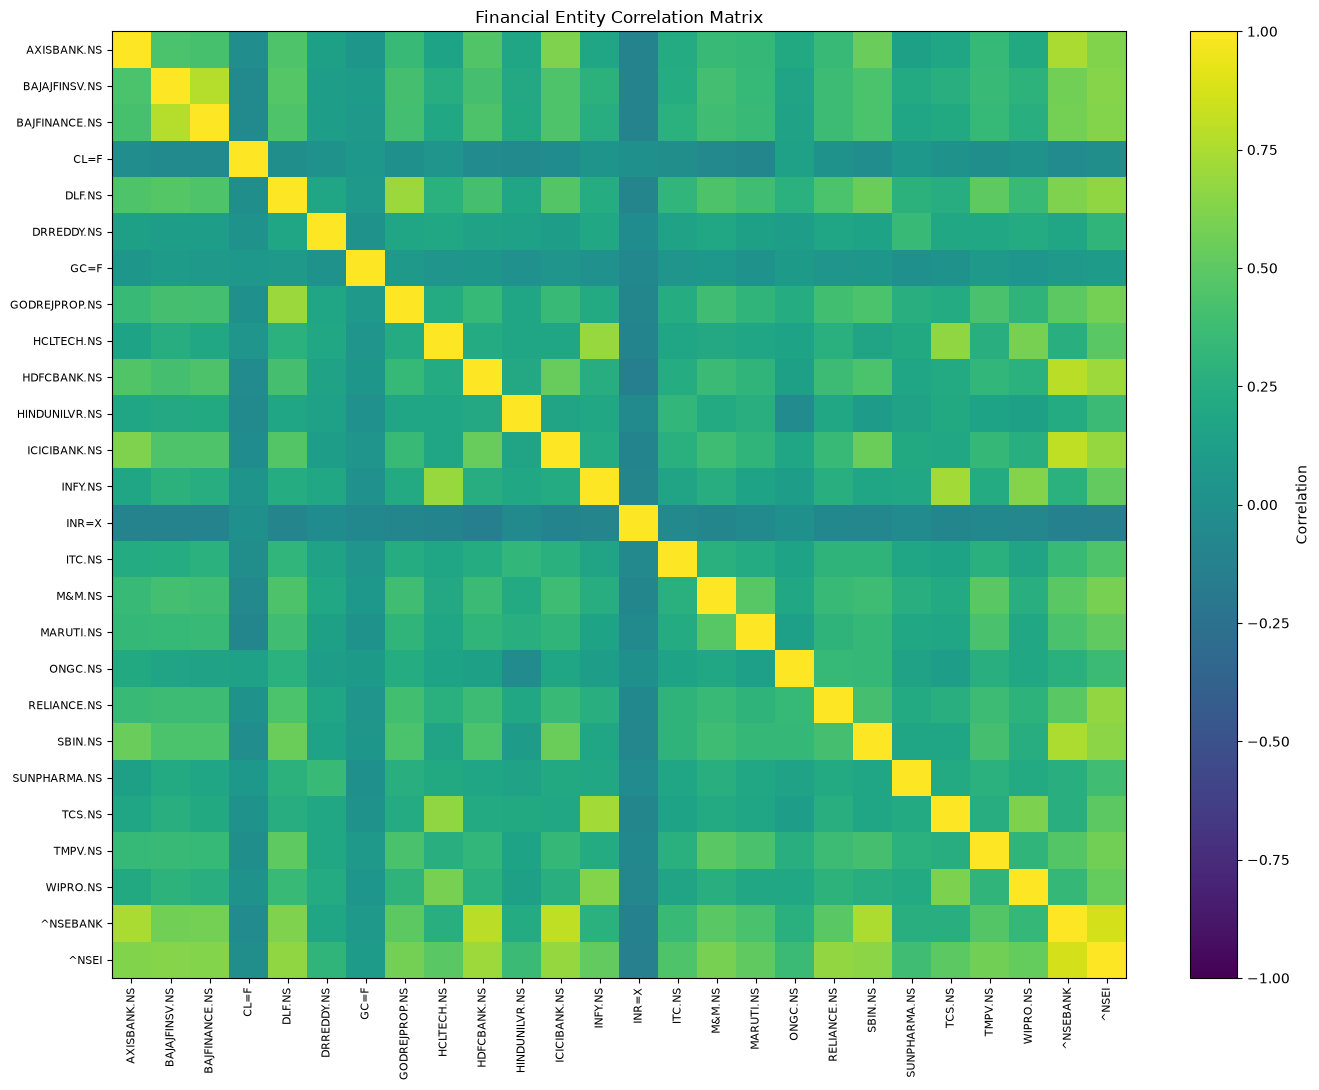

In [36]:
plt.figure(figsize=(14, 11))

plt.imshow(
    corr_matrix,
    aspect="auto",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=90,
    fontsize=8
)

plt.yticks(
    range(len(corr_matrix.index)),
    corr_matrix.index,
    fontsize=8
)

plt.title("Financial Entity Correlation Matrix")

plt.tight_layout()
plt.show()

In [37]:
correlation_pairs = []

columns = corr_matrix.columns

for i in range(len(columns)):
    for j in range(i + 1, len(columns)):
        correlation_pairs.append({
            "source": columns[i],
            "target": columns[j],
            "correlation": corr_matrix.iloc[i, j]
        })

correlation_pairs = pd.DataFrame(correlation_pairs)

print("Total unique relationships:", len(correlation_pairs))

correlation_pairs.head()

Total unique relationships: 325


,source,target,correlation
0,AXISBANK.NS,BAJAJFINSV.NS,0.437385
1,AXISBANK.NS,BAJFINANCE.NS,0.418688
2,AXISBANK.NS,CL=F,-0.017043
3,AXISBANK.NS,DLF.NS,0.448637
4,AXISBANK.NS,DRREDDY.NS,0.138981


In [38]:
correlation_pairs["strength"] = correlation_pairs["correlation"].abs()

correlation_pairs = correlation_pairs.sort_values(
    "strength",
    ascending=False
).reset_index(drop=True)

correlation_pairs.head(15)

,source,target,correlation,strength
0,^NSEBANK,^NSEI,0.871009,0.871009
1,ICICIBANK.NS,^NSEBANK,0.810765,0.810765
2,HDFCBANK.NS,^NSEBANK,0.789729,0.789729
3,BAJAJFINSV.NS,BAJFINANCE.NS,0.779670,0.779670
4,SBIN.NS,^NSEBANK,0.752013,0.752013
5,AXISBANK.NS,^NSEBANK,0.749901,0.749901
6,INFY.NS,TCS.NS,0.720184,0.720184
7,HDFCBANK.NS,^NSEI,0.710270,0.710270
8,DLF.NS,GODREJPROP.NS,0.703059,0.703059
9,HCLTECH.NS,INFY.NS,0.692098,0.692098


In [39]:
ticker_names = metadata.set_index("ticker")["name"].to_dict()

correlation_pairs["source_name"] = correlation_pairs["source"].map(ticker_names)
correlation_pairs["target_name"] = correlation_pairs["target"].map(ticker_names)

top_relationships = correlation_pairs[
    [
        "source",
        "source_name",
        "target",
        "target_name",
        "correlation",
        "strength"
    ]
].head(20)

top_relationships

,source,source_name,target,target_name,correlation,strength
0,^NSEBANK,Bank Nifty,^NSEI,NIFTY 50,0.871009,0.871009
1,ICICIBANK.NS,ICICI Bank,^NSEBANK,Bank Nifty,0.810765,0.810765
2,HDFCBANK.NS,HDFC Bank,^NSEBANK,Bank Nifty,0.789729,0.789729
3,BAJAJFINSV.NS,Bajaj Finserv,BAJFINANCE.NS,Bajaj Finance,0.779670,0.779670
4,SBIN.NS,SBI,^NSEBANK,Bank Nifty,0.752013,0.752013
5,AXISBANK.NS,Axis Bank,^NSEBANK,Bank Nifty,0.749901,0.749901
6,INFY.NS,Infosys,TCS.NS,TCS,0.720184,0.720184
7,HDFCBANK.NS,HDFC Bank,^NSEI,NIFTY 50,0.710270,0.710270
8,DLF.NS,DLF,GODREJPROP.NS,Godrej Properties,0.703059,0.703059
9,HCLTECH.NS,HCL Tech,INFY.NS,Infosys,0.692098,0.692098


In [40]:
thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

for threshold in thresholds:
    count = (
        correlation_pairs["strength"] >= threshold
    ).sum()

    print(
        f"|correlation| >= {threshold:.1f}: "
        f"{count} relationships"
    )

|correlation| >= 0.2: 190 relationships
|correlation| >= 0.3: 118 relationships
|correlation| >= 0.4: 71 relationships
|correlation| >= 0.5: 36 relationships
|correlation| >= 0.6: 22 relationships
|correlation| >= 0.7: 9 relationships


In [41]:
CORR_THRESHOLD = 0.40

graph_edges = correlation_pairs[
    correlation_pairs["strength"] >= CORR_THRESHOLD
].copy()

print("Threshold:", CORR_THRESHOLD)
print("Selected relationships:", len(graph_edges))

graph_edges[
    [
        "source_name",
        "target_name",
        "correlation",
        "strength"
    ]
].head(20)

Threshold: 0.4
Selected relationships: 71


,source_name,target_name,correlation,strength
0,Bank Nifty,NIFTY 50,0.871009,0.871009
1,ICICI Bank,Bank Nifty,0.810765,0.810765
2,HDFC Bank,Bank Nifty,0.789729,0.789729
3,Bajaj Finserv,Bajaj Finance,0.779670,0.779670
4,SBI,Bank Nifty,0.752013,0.752013
5,Axis Bank,Bank Nifty,0.749901,0.749901
6,Infosys,TCS,0.720184,0.720184
7,HDFC Bank,NIFTY 50,0.710270,0.710270
8,DLF,Godrej Properties,0.703059,0.703059
9,HCL Tech,Infosys,0.692098,0.692098


In [42]:
G = nx.Graph()

# Add all financial entities as nodes
for _, row in metadata.iterrows():
    G.add_node(
        row["ticker"],
        name=row["name"],
        type=row["type"],
        sector=row["sector"]
    )

# Add selected relationships as edges
for _, row in graph_edges.iterrows():

    relationship_type = (
        "positive"
        if row["correlation"] >= 0
        else "negative"
    )

    G.add_edge(
        row["source"],
        row["target"],
        correlation=float(row["correlation"]),
        weight=float(row["strength"]),
        relationship=relationship_type
    )

print("Graph created successfully.")
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Graph created successfully.
Nodes: 26
Edges: 71


In [43]:
print("Number of connected components:",
      nx.number_connected_components(G))

components = list(nx.connected_components(G))

for i, component in enumerate(
    sorted(components, key=len, reverse=True),
    start=1
):
    print(f"Component {i}: {len(component)} nodes")
    print(component)
    print()

Number of connected components: 8
Component 1: 19 nodes
{'RELIANCE.NS', '^NSEI', 'GODREJPROP.NS', '^NSEBANK', 'WIPRO.NS', 'HCLTECH.NS', 'ICICIBANK.NS', 'BAJAJFINSV.NS', 'TMPV.NS', 'AXISBANK.NS', 'DLF.NS', 'SBIN.NS', 'BAJFINANCE.NS', 'INFY.NS', 'M&M.NS', 'TCS.NS', 'ITC.NS', 'HDFCBANK.NS', 'MARUTI.NS'}

Component 2: 1 nodes
{'INR=X'}

Component 3: 1 nodes
{'CL=F'}

Component 4: 1 nodes
{'GC=F'}

Component 5: 1 nodes
{'ONGC.NS'}

Component 6: 1 nodes
{'SUNPHARMA.NS'}

Component 7: 1 nodes
{'DRREDDY.NS'}

Component 8: 1 nodes
{'HINDUNILVR.NS'}



In [44]:
isolated_nodes = list(nx.isolates(G))

print("Isolated nodes:", len(isolated_nodes))

for node in isolated_nodes:
    print(node, "-", G.nodes[node]["name"])

Isolated nodes: 7
INR=X - USD/INR
CL=F - Crude Oil
GC=F - Gold
ONGC.NS - ONGC
SUNPHARMA.NS - Sun Pharma
DRREDDY.NS - Dr Reddy's
HINDUNILVR.NS - Hindustan Unilever


In [45]:
degree_centrality = nx.degree_centrality(G)

betweenness_centrality = nx.betweenness_centrality(
    G,
    weight=None
)

centrality_df = pd.DataFrame({
    "ticker": list(G.nodes()),
    "degree_centrality": [
        degree_centrality[node]
        for node in G.nodes()
    ],
    "betweenness_centrality": [
        betweenness_centrality[node]
        for node in G.nodes()
    ]
})

centrality_df["name"] = centrality_df["ticker"].map(
    metadata.set_index("ticker")["name"]
)

centrality_df["sector"] = centrality_df["ticker"].map(
    metadata.set_index("ticker")["sector"]
)

centrality_df = centrality_df[
    [
        "ticker",
        "name",
        "sector",
        "degree_centrality",
        "betweenness_centrality"
    ]
]

centrality_df.head()

,ticker,name,sector,degree_centrality,betweenness_centrality
0,^NSEI,NIFTY 50,Market,0.72,0.2595
1,^NSEBANK,Bank Nifty,Banking,0.52,0.0295
2,INR=X,USD/INR,Macro,0.00,0.0000
3,CL=F,Crude Oil,Energy,0.00,0.0000
4,GC=F,Gold,Safe Haven,0.00,0.0000


In [46]:
centrality_df.sort_values(
    "degree_centrality",
    ascending=False
).head(10)

,ticker,name,sector,degree_centrality,betweenness_centrality
0,^NSEI,NIFTY 50,Market,0.72,0.259500
1,^NSEBANK,Bank Nifty,Banking,0.52,0.029500
18,DLF.NS,DLF,Realty,0.48,0.017000
7,SBIN.NS,SBI,Banking,0.44,0.011222
25,BAJAJFINSV.NS,Bajaj Finserv,NBFC,0.40,0.006333
24,BAJFINANCE.NS,Bajaj Finance,NBFC,0.36,0.001667
6,ICICIBANK.NS,ICICI Bank,Banking,0.32,0.000000
5,HDFCBANK.NS,HDFC Bank,Banking,0.32,0.000000
8,AXISBANK.NS,Axis Bank,Banking,0.32,0.000000
15,TMPV.NS,Tata Motors Passenger Vehicles,Auto,0.28,0.004389


In [47]:
centrality_df.sort_values(
    "betweenness_centrality",
    ascending=False
).head(10)

,ticker,name,sector,degree_centrality,betweenness_centrality
0,^NSEI,NIFTY 50,Market,0.72,0.259500
1,^NSEBANK,Bank Nifty,Banking,0.52,0.029500
18,DLF.NS,DLF,Realty,0.48,0.017000
7,SBIN.NS,SBI,Banking,0.44,0.011222
25,BAJAJFINSV.NS,Bajaj Finserv,NBFC,0.40,0.006333
15,TMPV.NS,Tata Motors Passenger Vehicles,Auto,0.28,0.004389
16,M&M.NS,Mahindra & Mahindra,Auto,0.24,0.002500
24,BAJFINANCE.NS,Bajaj Finance,NBFC,0.36,0.001667
19,GODREJPROP.NS,Godrej Properties,Realty,0.28,0.001222
2,INR=X,USD/INR,Macro,0.00,0.000000


In [48]:
for node in G.nodes():

    G.nodes[node]["degree_centrality"] = float(
        degree_centrality[node]
    )

    G.nodes[node]["betweenness_centrality"] = float(
        betweenness_centrality[node]
    )

print("Centrality attributes added.")

Centrality attributes added.


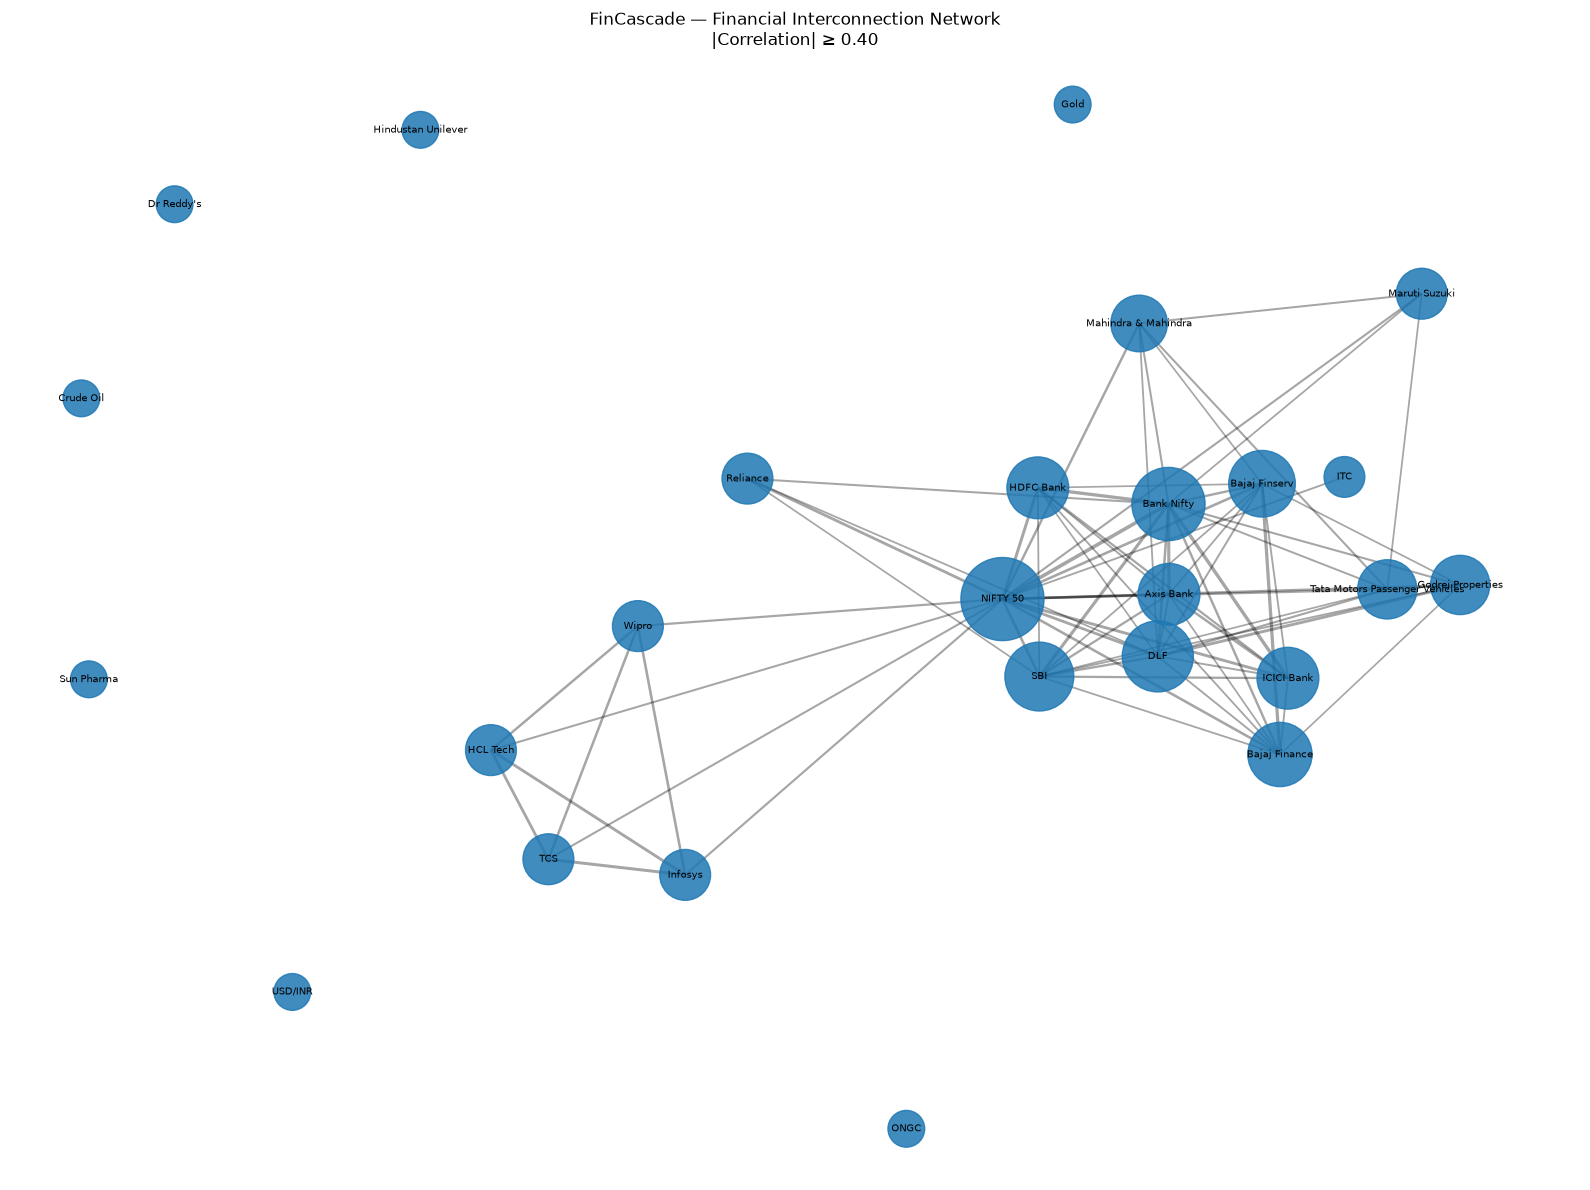

In [49]:
plt.figure(figsize=(16, 12))

pos = nx.spring_layout(
    G,
    seed=42,
    k=0.8
)

node_sizes = [
    700 + degree_centrality[node] * 4000
    for node in G.nodes()
]

edge_widths = [
    G[u][v]["weight"] * 3
    for u, v in G.edges()
]

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=node_sizes,
    alpha=0.85
)

nx.draw_networkx_edges(
    G,
    pos,
    width=edge_widths,
    alpha=0.35
)

labels = {
    node: G.nodes[node]["name"]
    for node in G.nodes()
}

nx.draw_networkx_labels(
    G,
    pos,
    labels,
    font_size=7
)

plt.title(
    "FinCascade — Financial Interconnection Network\n"
    "|Correlation| ≥ 0.40"
)

plt.axis("off")
plt.tight_layout()
plt.show()

In [50]:
graph_edges.to_csv(
    DATA_DIR / "relationships_correlation.csv",
    index=False
)

centrality_df.to_csv(
    DATA_DIR / "centrality_metrics.csv",
    index=False
)

print("Relationship and centrality files saved.")

Relationship and centrality files saved.


In [51]:
graph_edges.to_csv(
    DATA_DIR / "relationships_correlation.csv",
    index=False
)

centrality_df.to_csv(
    DATA_DIR / "centrality_metrics_correlation.csv",
    index=False
)

print("Baseline graph data saved.")

Baseline graph data saved.


In [52]:
def lagged_correlation(source, target, max_lag=5):
    
    results = []

    for lag in range(1, max_lag + 1):

        # Source movement today
        x = returns_model[source]

        # Target movement after 'lag' days
        y = returns_model[target].shift(-lag)

        temp = pd.concat([x, y], axis=1).dropna()

        corr = temp.iloc[:, 0].corr(temp.iloc[:, 1])

        results.append({
            "lag": lag,
            "correlation": corr,
            "strength": abs(corr)
        })

    return pd.DataFrame(results)

In [53]:
test_lag = lagged_correlation(
    "CL=F",
    "ONGC.NS",
    max_lag=5
)

test_lag

,lag,correlation,strength
0,1,0.247247,0.247247
1,2,-0.016228,0.016228
2,3,0.020429,0.020429
3,4,0.000332,0.000332
4,5,-0.021914,0.021914


In [54]:
lagged_relationships = []

tickers = list(returns_model.columns)

for source in tickers:

    for target in tickers:

        if source == target:
            continue

        result = lagged_correlation(
            source,
            target,
            max_lag=5
        )

        best = result.loc[
            result["strength"].idxmax()
        ]

        lagged_relationships.append({
            "source": source,
            "target": target,
            "best_lag": int(best["lag"]),
            "lag_correlation": float(best["correlation"]),
            "lag_strength": float(best["strength"])
        })

lagged_df = pd.DataFrame(lagged_relationships)

print("Directional relationships tested:",
      len(lagged_df))

lagged_df.head()

Directional relationships tested: 650


,source,target,best_lag,lag_correlation,lag_strength
0,AXISBANK.NS,BAJAJFINSV.NS,4,0.081574,0.081574
1,AXISBANK.NS,BAJFINANCE.NS,4,0.046000,0.046000
2,AXISBANK.NS,CL=F,5,0.056602,0.056602
3,AXISBANK.NS,DLF.NS,5,0.054388,0.054388
4,AXISBANK.NS,DRREDDY.NS,2,0.026896,0.026896


In [55]:
ticker_name_map = metadata.set_index(
    "ticker"
)["name"].to_dict()

ticker_sector_map = metadata.set_index(
    "ticker"
)["sector"].to_dict()

lagged_df["source_name"] = (
    lagged_df["source"].map(ticker_name_map)
)

lagged_df["target_name"] = (
    lagged_df["target"].map(ticker_name_map)
)

lagged_df["source_sector"] = (
    lagged_df["source"].map(ticker_sector_map)
)

lagged_df["target_sector"] = (
    lagged_df["target"].map(ticker_sector_map)
)

In [56]:
lagged_df.sort_values(
    "lag_strength",
    ascending=False
)[
    [
        "source_name",
        "target_name",
        "best_lag",
        "lag_correlation",
        "lag_strength"
    ]
].head(20)

,source_name,target_name,best_lag,lag_correlation,lag_strength
91,Crude Oil,ONGC,1,0.247247,0.247247
638,NIFTY 50,USD/INR,1,-0.149673,0.149673
187,Godrej Properties,USD/INR,1,-0.132119,0.132119
84,Crude Oil,Hindustan Unilever,1,-0.129873,0.129873
613,Bank Nifty,USD/INR,1,-0.129610,0.129610
112,DLF,USD/INR,1,-0.128887,0.128887
162,Gold,USD/INR,1,-0.126230,0.126230
488,SBI,USD/INR,1,-0.123731,0.123731
619,Bank Nifty,SBI,4,0.115906,0.115906
166,Gold,ONGC,1,0.114103,0.114103


In [58]:
LAG_THRESHOLD = 0.10

lagged_filtered = lagged_df[
    lagged_df["lag_strength"] >= LAG_THRESHOLD
].copy()

lagged_filtered = lagged_filtered.sort_values(
    "lag_strength",
    ascending=False
).reset_index(drop=True)

print("Lag threshold:", LAG_THRESHOLD)
print("Selected lagged relationships:", len(lagged_filtered))

display(
    lagged_filtered[
        [
            "source_name",
            "target_name",
            "best_lag",
            "lag_correlation",
            "lag_strength"
        ]
    ]
)

Lag threshold: 0.1
Selected lagged relationships: 16


,source_name,target_name,best_lag,lag_correlation,lag_strength
0,Crude Oil,ONGC,1,0.247247,0.247247
1,NIFTY 50,USD/INR,1,-0.149673,0.149673
2,Godrej Properties,USD/INR,1,-0.132119,0.132119
3,Crude Oil,Hindustan Unilever,1,-0.129873,0.129873
4,Bank Nifty,USD/INR,1,-0.129610,0.129610
5,DLF,USD/INR,1,-0.128887,0.128887
6,Gold,USD/INR,1,-0.126230,0.126230
7,SBI,USD/INR,1,-0.123731,0.123731
8,Bank Nifty,SBI,4,0.115906,0.115906
9,Gold,ONGC,1,0.114103,0.114103


In [59]:
lagged_df.to_csv(
    DATA_DIR / "relationships_lagged_all.csv",
    index=False
)

lagged_filtered.to_csv(
    DATA_DIR / "relationships_lagged_filtered.csv",
    index=False
)

print("All lagged relationships:", len(lagged_df))
print("Filtered relationships :", len(lagged_filtered))
print("Files saved successfully.")

All lagged relationships: 650
Filtered relationships : 16
Files saved successfully.
